# Clustering Project: Northwind Traders

## The Situation:
You work as a Data Scientist for Northwind Traders, a wholesale distributor that supplies gourmet food products to restaurants, cafes, and specialty food retailers

## The assignment:
You have access to their yearly client report, which includes the channel & region for each client, as well as their total spend by product categories in the last year. Your task is to use clustering techniques to understand the different client segments so the company can better cater to and support each type

## The objectives:
1. Scale the data
2. Apply 3 different clustering techniques
3. Compare the segments using silhouette score & intuition and select the “best” segments
4. Predict the cluster of a new client

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 1. Data Prep

In [2]:
# Read in the data file
file_path = Path.cwd().parent
# file_path = Path.cwd().parent / 'data' / 'raw' / 'wholesale_clients.csv'
df = pd.read_csv(str(file_path) + '/data/raw/wholesale_clients.csv')

In [3]:
# Show the first lines of the dataset
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
# Check for nan values and dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
# Show the distribution of the data
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [6]:
# Remove the Channel (restaurant, hotel, etc.) and Region columns since they are not fields we want to model on
df_clean = df.drop(['Channel', 'Region'], axis=1)
df_clean.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [7]:
# Extract the columns names
column_names = df_clean.columns
column_names

Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'], dtype='object')

In [8]:
# Note the number of rows and columns
df_clean.shape

(440, 6)

In [9]:
# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(data=data_scaled, columns=column_names)
df_scaled

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347
...,...,...,...,...,...,...
435,1.401312,0.848446,0.850760,2.075222,-0.566831,0.241091
436,2.155293,-0.592142,-0.757165,0.296561,-0.585519,0.291501
437,0.200326,1.314671,2.348386,-0.543380,2.511218,0.121456
438,-0.135384,-0.517536,-0.602514,-0.419441,-0.569770,0.213046


In [10]:
# Double check that all the column means are 0 and standard deviations are 1
df_scaled.describe().map('{:.3f}'.format)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000,440.000,440.000,440.000,440.000,440.000
mean,-0.000,0.000,-0.000,0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001
min,-0.950,-0.779,-0.837,-0.628,-0.604,-0.540
25%,-0.702,-0.578,-0.611,-0.480,-0.551,-0.396
50%,-0.277,-0.294,-0.337,-0.319,-0.434,-0.199
75%,0.391,0.189,0.285,0.099,0.218,0.105
max,7.928,9.184,8.937,11.919,7.968,16.478


In [11]:
df_scaled.to_csv(str(file_path) + '/data/processed/scaled_data.csv')

## 2. K-Means Clustering

In [12]:
# Import KMeans and write a loop to fit models with 2 to 15 clusters
inertia_values = []
for i in range(2, 15):
  kmeans = KMeans(n_clusters=i, random_state=91)
  kmeans.fit(df_scaled)
  inertia_values.append(kmeans.inertia_)

inertia_values

[1954.6767320566746,
 1642.7302773007782,
 1325.8438271034202,
 1062.630348433636,
 947.695457475789,
 853.8066189365081,
 804.5897320387849,
 686.7378134508024,
 640.2530055681507,
 580.3914474903528,
 541.6275603159883,
 494.9831890815865,
 460.0288877339084]

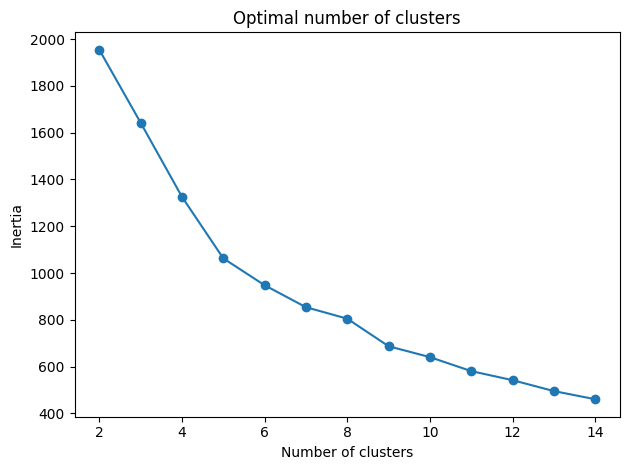

In [60]:
# Create an inertia plot
plt.plot(range(2, 15), inertia_values, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Optimal number of clusters')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/kmeans_inertia_plot.png')
plt.show();

In [14]:
# sns.set_style('darkgrid')
# sns.lineplot(x=range(2, 15), y=inertia_values, marker='o')
# plt.xlabel('Number of clusters')
# plt.ylabel('Inertia')
# plt.title('Optimal number of clusters')
# plt.show();

In [15]:
# Identify the elbow of the plot and fit a KMeans model just for that number of clusters - Elbow = 5
kmeans_1 = KMeans(n_clusters=5, random_state=91)
clusters = kmeans_1.fit(df_scaled)
cluster_labels = clusters.labels_
cluster_labels

array([2, 4, 4, 2, 0, 2, 2, 2, 2, 4, 4, 2, 4, 4, 4, 2, 4, 2, 2, 2, 2, 2,
       0, 1, 4, 2, 2, 2, 4, 0, 2, 2, 2, 0, 2, 4, 0, 4, 4, 0, 0, 2, 4, 4,
       4, 4, 4, 1, 4, 4, 2, 2, 0, 4, 2, 2, 1, 4, 2, 2, 2, 1, 2, 4, 2, 1,
       2, 4, 2, 2, 0, 0, 2, 0, 2, 2, 2, 4, 2, 2, 2, 4, 4, 2, 2, 1, 1, 0,
       2, 2, 2, 2, 1, 0, 4, 2, 2, 2, 2, 2, 4, 4, 2, 0, 2, 2, 4, 4, 2, 4,
       2, 4, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 4, 4, 2, 4, 4, 4, 2, 2, 4, 2, 4, 4, 2, 2, 2, 4, 4, 2, 4, 2, 4,
       0, 2, 2, 2, 2, 0, 4, 3, 2, 2, 2, 2, 4, 4, 2, 2, 2, 4, 2, 2, 0, 4,
       2, 2, 4, 4, 0, 2, 2, 4, 2, 2, 2, 4, 2, 1, 2, 2, 4, 4, 4, 2, 4, 2,
       2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 4, 4, 2, 2, 2, 2, 2, 1, 2, 2, 4, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       4, 4, 4, 2, 4, 2, 2, 2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2, 0, 0, 0, 0,
       2, 2, 2, 0, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2,

In [16]:
# combine the data and cluster labels
# labels_df = pd.Series(cluster_labels, name='cluster')
# df_clusters = pd.concat([df_clean, labels_df], axis=1)
# df_clusters.head()

In [17]:
df_clusters_norm = pd.concat([df_scaled, pd.Series(cluster_labels, name='clusters')], axis=1)
df_clusters_norm.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,clusters
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339,2
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151,4
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293,4
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411,2
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347,0


In [18]:
# d. Find the number of clients in each cluster
# df_clusters['cluster'].value_counts()

In [19]:
# from mpl_toolkits.mplot3d import Axes3D

# fig = plt.figure(figsize=(8, 6))
# ax = Axes3D(fig)
# fig.add_axes(ax)

# sc = ax.scatter(df_clusters[column_names[3]], df_clusters[column_names[4]], df_clusters[column_names[5]], c=df_clusters['cluster'], cmap='tab10')

# ax.set_xlabel(column_names[3])
# ax.set_ylabel(column_names[4])
# ax.set_zlabel(column_names[5])

# plt.legend(*sc.legend_elements(), title='clusters', bbox_to_anchor=(1.15, 1));

In [20]:
# Identify cluster centers
cluster_centers = clusters.cluster_centers_
df_centers = pd.DataFrame(cluster_centers, columns=column_names)
df_centers

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.758842,-0.129474,-0.251284,1.342152,-0.423756,0.407552
1,0.388729,3.943049,4.021646,0.035784,4.226116,0.941636
2,-0.178984,-0.375194,-0.426856,-0.157027,-0.398374,-0.190295
3,1.966817,5.175503,1.287217,6.900600,-0.554862,16.478447
4,-0.492434,0.648068,0.893137,-0.343047,0.899478,0.052198


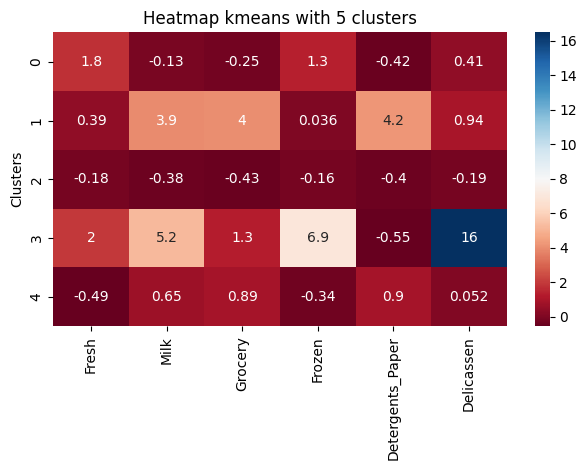

In [65]:
# Create a heat map of the cluster centers
sns.heatmap(df_centers, cmap='RdBu', annot=True)
plt.title('Heatmap kmeans with 5 clusters')
plt.ylabel('Clusters')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/heatmap_5clusters.png')
plt.show();

In [22]:
# cluster_profile = df_clusters.groupby('cluster')[df_clean.columns].mean().round(1)
# cluster_profile

In [23]:
# sns.heatmap(cluster_profile, cmap='RdBu', annot=True, fmt='.0f')
# plt.show();

## Suggested clusters
0:	Fresh & Frozen Specialists:	Very high Fresh and Frozen purchases, slightly above average Delicassen, but below average Milk, Grocery, and Detergents/Paper.

1:	Supermarket / Bulk Grocery: Buyers	Extremely high Milk, Grocery, and Detergents/Paper spending, with moderately high Fresh and Delicassen.

2:	Low-Spending General Customers:	Below average in every category, suggesting small or infrequent buyers.

3:	Gourmet / High-End Food Buyers:	Exceptionally high Delicassen and Frozen, very high Milk and Fresh, but low Detergents/Paper. Likely specialty food businesses or gourmet restaurants.

4:	Household & Grocery-Oriented Buyers:	Above average Grocery, Milk, and Detergents/Paper, but below average Fresh and Frozen.

In [24]:
# Name the clusters
cluster_names = {
  0: 'Fresh & Frozen',
  1: 'Bulk Grocery',
  2: 'General Customers',
  3: 'Gourmet',
  4: 'Household & Grocery'
}

In [25]:
# Identify the silhouette scores for 2 to 15 clusters
from sklearn.metrics import silhouette_score

sil_values = []
for k in range(2, 15):
  kmeans = KMeans(n_clusters=k, random_state=91, n_init=100)
  kmeans_fit = kmeans.fit(df_scaled)
  sil_score = silhouette_score(df_scaled, kmeans_fit.labels_)
  sil_values.append(sil_score)

sil_values

[0.5810874672125177,
 0.53836620585661,
 0.3546109298192704,
 0.36807191214496154,
 0.37438369639182345,
 0.31231525767617824,
 0.31495854567750087,
 0.3064400726986866,
 0.3108109490948497,
 0.3114768318937444,
 0.28723705167499763,
 0.2763143353434553,
 0.298005325360002]

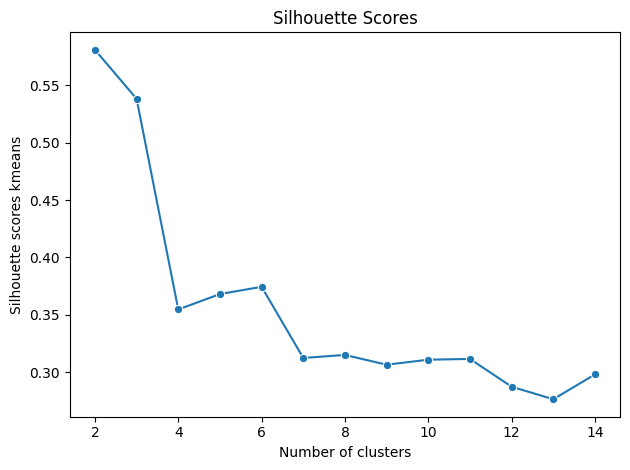

In [67]:
# Create a silhouette scores plot instead of an inertia plot
sns.lineplot(x=range(2, 15), y=sil_values, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette scores kmeans')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/silhouette_scores_kmeans.png')
plt.show();

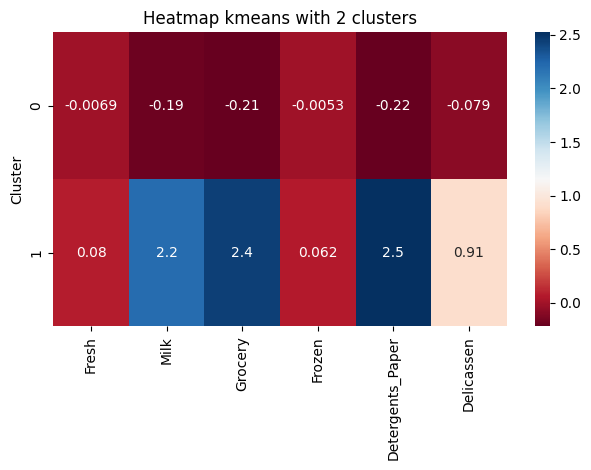

In [68]:
# Fit two models with the number of clusters for the two highest silhouette scores and name the clusters
kmeans_s2 = KMeans(n_clusters=2, random_state=91, n_init='auto')
clusters_s2 = kmeans_s2.fit(df_scaled)
# cluster_labels_s2 = clusters_s2.labels_
# df_clusters_s2 = pd.concat([df_scaled, pd.Series(cluster_labels_s2, name='Cluster')], axis=1)
# df_clusters_s2.head()

sns.heatmap(pd.DataFrame(clusters_s2.cluster_centers_, columns=column_names), cmap='RdBu', annot=True)
plt.title('Heatmap kmeans with 2 clusters')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/heatmap_2clusters.png')
plt.show();

- Cluster 0: **small amount**
- Cluster 1: **large amount**

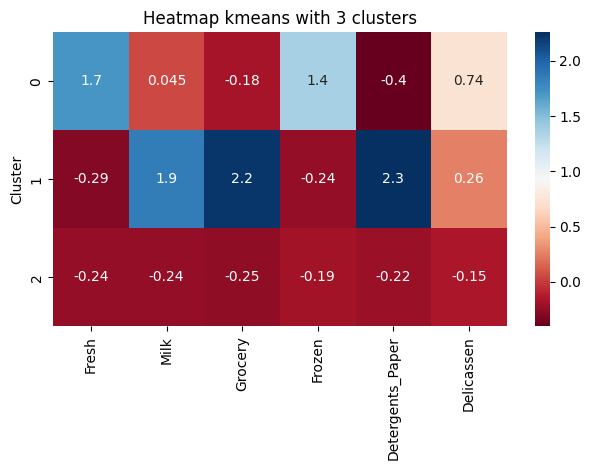

In [69]:
kmeans_s3 = KMeans(n_clusters=3, random_state=91, n_init='auto')
clusters_s3 = kmeans_s3.fit(df_scaled)

sns.heatmap(pd.DataFrame(clusters_s3.cluster_centers_, columns=column_names), cmap='RdBu', annot=True)
plt.title('Heatmap kmeans with 3 clusters')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/heatmap_3clusters.png')
plt.show();

- Cluster 0: **Fresh-frozen-deli**
- Cluster 1: **Milk-groceries-DP**
- Cluster 2: **Small amount**

## 3. Hierarchical Clustering

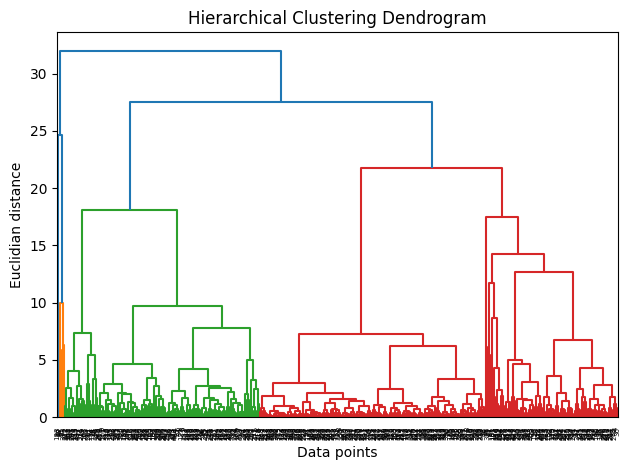

In [72]:
# Create a dendrogram using the scaled data
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_matrix = linkage(df_scaled, method='ward')
dendrogram_info = dendrogram(linkage_matrix)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidian distance')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/dendrogram_1.png')
plt.show();

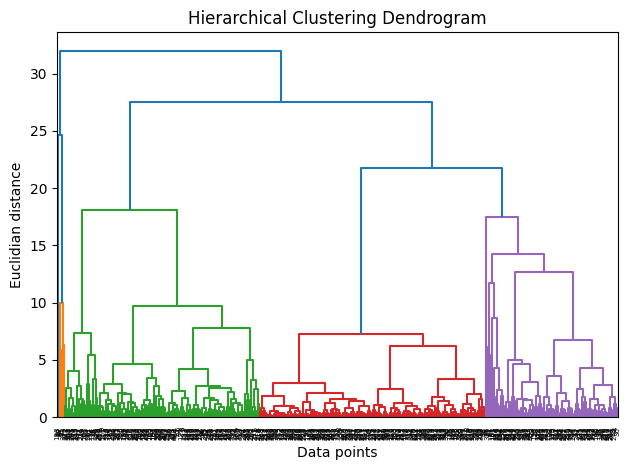

In [73]:
# Identify the number of clusters and update the color threadshold
dendrogram_info = dendrogram(linkage_matrix, color_threshold=20)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidian distance')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/dendrogram_2.png')
plt.show();

In [31]:
# Fit an agglomerative clustering model on the scaled data set with the "best" clusters and view the number of data points in each cluster
from sklearn.cluster import AgglomerativeClustering
from collections import Counter

agg5 = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
agg5.fit(df_scaled)
Counter(agg5.labels_)

Counter({np.int64(4): 177,
         np.int64(0): 153,
         np.int64(2): 104,
         np.int64(1): 5,
         np.int64(3): 1})

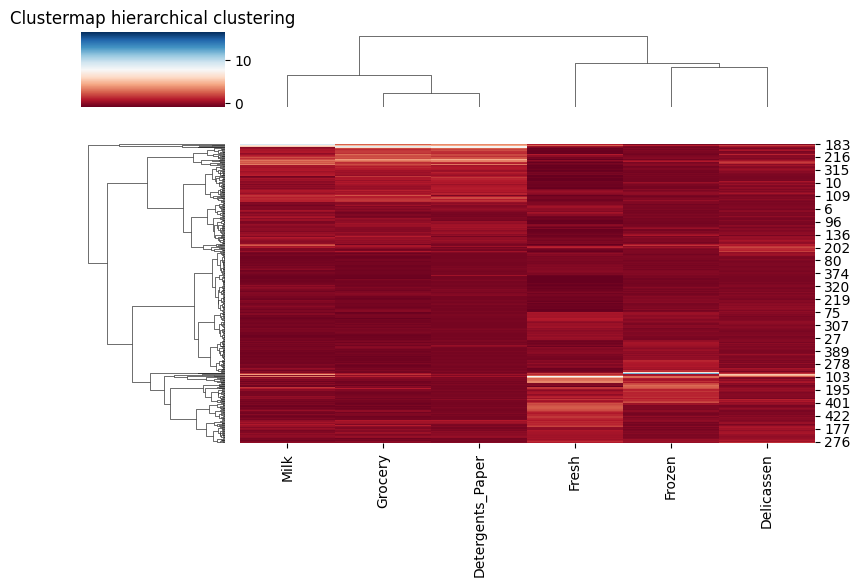

In [76]:
# Create a cluster map of the model
sns.clustermap(df_scaled, method='ward', cmap='RdBu', xticklabels=column_names, figsize=(8, 6))
plt.title('Clustermap hierarchical clustering')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/clustermap_1.png')
plt.show();

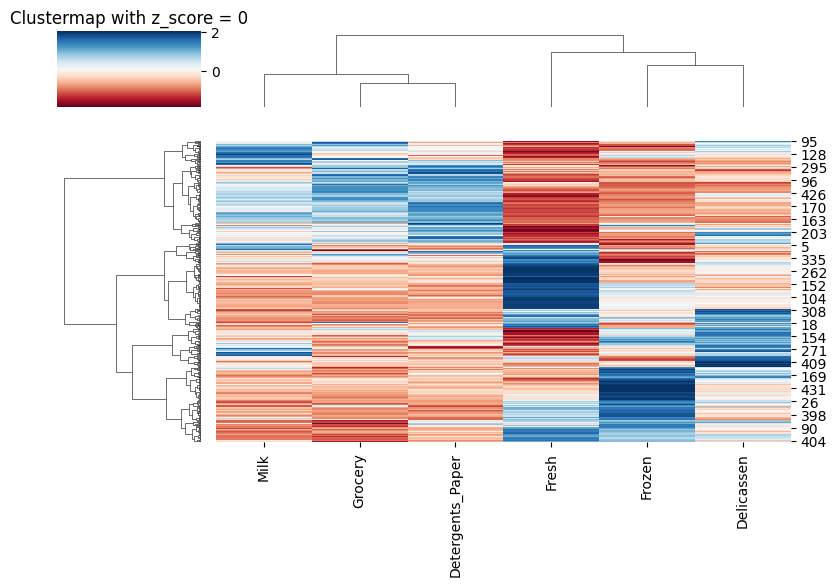

In [77]:
# Standardized the rows with z_score=0 and visualize the results
sns.clustermap(df_scaled, method='ward', cmap='RdBu', xticklabels=column_names, figsize=(8, 6), z_score=0)
plt.title('Clustermap with z_score = 0')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/clustermap_2')
plt.show();

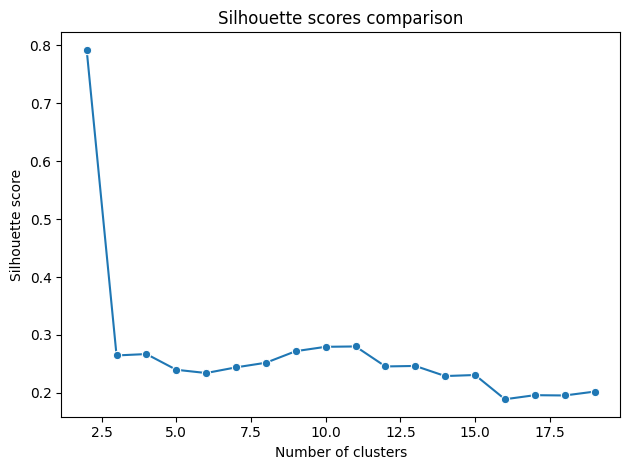

In [78]:
# f. Write a loop to view the silhouette score for 2 to 20 clusters
silhouette_scores = []

for i in range(2, 20):
  agg = AgglomerativeClustering(i)
  agg.fit(df_scaled)
  agg_labels = agg.labels_
  sil_score = silhouette_score(df_scaled, agg_labels)
  silhouette_scores.append(sil_score)

sns.lineplot(x=range(2, 20), y=silhouette_scores, marker='o')
plt.title('Silhouette scores comparison')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/silhouette_scores_agglomerative.png')
plt.show();

In [35]:
# Fit a model with the number of clusters for the highest silhouette score
agg2 = AgglomerativeClustering(n_clusters=2)
agg2.fit(df_scaled)

Counter(agg2.labels_)

Counter({np.int64(0): 434, np.int64(1): 6})

## 4. DBSCAN

In [36]:
# Create a function to fit and tune a DBSCAN model
from sklearn.cluster import DBSCAN

def tune_dbscan(data):

    results = []

    # define a range of eps and min_samples values to loop through
    eps_values = np.arange(.1, 2, .1)
    min_samples_values = np.arange(2, 10, 1)

    # loop through the combinations of eps and min_samples
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            dbscan.fit(data)
            labels = dbscan.labels_

            # count the number of clusters (excluding noise points labeled as -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # count the number of noise points (labeled as -1)
            n_noise = list(labels).count(-1)

            # calculate the silhouette score (excluding noise points)
            if n_clusters > 1:  # silhouette score requires at least 2 clusters
                silhouette = silhouette_score(data, labels, metric='euclidean', sample_size=None)
            else:
                silhouette = None

            results.append([eps, min_samples, n_clusters, n_noise, silhouette])

    # put the results in a dataframe
    dbscan_results = pd.DataFrame(results, columns=["Eps", "Min Samples", "Number of Clusters",
                                                    "Number of Noise Points", "Silhouette Score"])
    return dbscan_results

In [37]:
# Apply the dbscan function on the scaled data
dbscan_results = tune_dbscan(df_scaled)
dbscan_results

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,0.1,2,8,423,-0.393
1,0.1,3,1,437,NaN
2,0.1,4,0,440,NaN
3,0.1,5,0,440,NaN
4,0.1,6,0,440,NaN
...,...,...,...,...,...
147,1.9,5,1,15,NaN
148,1.9,6,1,18,NaN
149,1.9,7,1,18,NaN
150,1.9,8,1,19,NaN


In [38]:
# Sort the data by highest silhouette score
dbscan_results.sort_values(by='Silhouette Score', ascending=False)

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
136,1.8,2,2,13,0.581583
122,1.6,4,2,24,0.578543
96,1.3,2,3,25,0.424572
97,1.3,3,3,25,0.424572
105,1.4,3,3,23,0.423547
...,...,...,...,...,...
147,1.9,5,1,15,NaN
148,1.9,6,1,18,NaN
149,1.9,7,1,18,NaN
150,1.9,8,1,19,NaN


In [39]:
# # Update the function to test eps values up to 5 (instead of 2)
# def tune_dbscan(data):

#     results = []

#     # define a range of eps and min_samples values to loop through
#     eps_values = np.arange(.1, 5, .1)
#     min_samples_values = np.arange(2, 10, 1)

#     # loop through the combinations of eps and min_samples
#     for eps in eps_values:
#         for min_samples in min_samples_values:
#             dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#             dbscan.fit(data)
#             labels = dbscan.labels_

#             # count the number of clusters (excluding noise points labeled as -1)
#             n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

#             # count the number of noise points (labeled as -1)
#             n_noise = list(labels).count(-1)

#             # calculate the silhouette score (excluding noise points)
#             if n_clusters > 1:  # silhouette score requires at least 2 clusters
#                 silhouette = silhouette_score(data, labels, metric='euclidean', sample_size=None)
#             else:
#                 silhouette = None

#             results.append([eps, min_samples, n_clusters, n_noise, silhouette])

#     # put the results in a dataframe
#     dbscan_results = pd.DataFrame(results, columns=["Eps", "Min Samples", "Number of Clusters",
#                                                     "Number of Noise Points", "Silhouette Score"])
#     return dbscan_results

In [40]:
# # Apply the function again and view the top silhouette scores
# new_results = tune_dbscan(df_scaled)
# new_results.sort_values(by='Silhouette Score', ascending=False)

In [41]:
# Update the function to test eps values up to 5 (instead of 2)
from src.utils import tune_dbscan

new_results = tune_dbscan(df_scaled, 5)
new_results.sort_values(by='Silhouette Score', ascending=False)

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
256,3.3,2,2,8,0.740284
248,3.2,2,2,8,0.740284
264,3.4,2,2,8,0.740284
272,3.5,2,2,8,0.740284
200,2.6,2,2,10,0.582247
...,...,...,...,...,...
387,4.9,5,1,5,NaN
388,4.9,6,1,5,NaN
389,4.9,7,1,5,NaN
390,4.9,8,1,6,NaN


In [42]:
# Fit a DBSCAN model on the scaled data set with the best eps + min_samples values and view the number of data points in each cluster
dbscan1 = DBSCAN(eps=3.3, min_samples=2)
dbscan1.fit(df_scaled)
Counter(dbscan1.labels_)

Counter({np.int64(0): 430, np.int64(-1): 8, np.int64(1): 2})

## 5. Compare Techniques

For each of the following 5 models, fit the model on the scaled data, note down the number of data points in each cluster and record the silhouette score:
1. K-Means with 3 clusters
2. K-Means with 5 clusters
3. Hiearchical Clustering with 2 clusters
4. Hierarchical Clustering with 5 clusters
5. DBSCAN with 2 clusters

In [43]:
# def display_results(model, data):
#   print(model)
#   print(Counter(model.labels_))
#   print(silhouette_score(data, model.labels_))

In [44]:
from src.utils import display_results

In [45]:
display_results(kmeans_s3, df_scaled)

KMeans(n_clusters=3, random_state=91)
Counter({np.int32(2): 341, np.int32(0): 56, np.int32(1): 43})
0.4485028522415343


In [46]:
display_results(kmeans_1, df_scaled)

KMeans(n_clusters=5, random_state=91)
Counter({np.int32(2): 279, np.int32(4): 97, np.int32(0): 52, np.int32(1): 11, np.int32(3): 1})
0.37006227092537314


In [47]:
display_results(agg2, df_scaled)

AgglomerativeClustering()
Counter({np.int64(0): 434, np.int64(1): 6})
0.7924572758342273


In [48]:
display_results(agg5, df_scaled)

AgglomerativeClustering(n_clusters=5)
Counter({np.int64(4): 177, np.int64(0): 153, np.int64(2): 104, np.int64(1): 5, np.int64(3): 1})
0.23988371669170097


In [49]:
display_results(dbscan1, df_scaled)

DBSCAN(eps=3.3, min_samples=2)
Counter({np.int64(0): 430, np.int64(-1): 8, np.int64(1): 2})
0.740283564230615


In [58]:
import joblib
joblib.dump(kmeans_s3, str(file_path) + '/models/kmeans3_model.pkl')
joblib.dump(kmeans_1, str(file_path) + '/models/kmeans5_model.pkl')
joblib.dump(agg2, str(file_path) + '/models/hierarchical2_model.pkl')
joblib.dump(agg5, str(file_path) + '/models/hierarchical5_model.pkl')
joblib.dump(dbscan1, str(file_path) + '/models/dbscan2_model.pkl')

['d:\\Programming\\PersonalProjects\\data_science\\clustering_northwind_traders/models/dbscan2_model.pkl']

## 6. Recommend Client Segments

In [50]:
# With the top model as the K-Means model with 3 clusters, review the results again
kmeans3 = KMeans(n_clusters=3, n_init='auto', random_state=91)
kmeans3.fit(df_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,91
,copy_x,True
,algorithm,'lloyd'


In [51]:
Counter(kmeans3.labels_)

Counter({np.int32(2): 341, np.int32(0): 56, np.int32(1): 43})

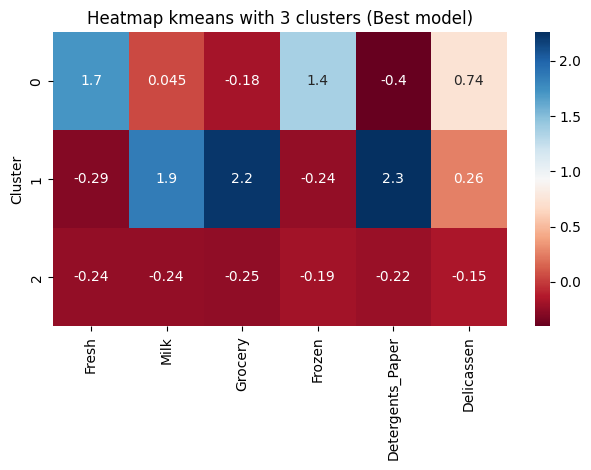

In [79]:
kmeans3_centers = pd.DataFrame(kmeans3.cluster_centers_, columns=column_names)
sns.heatmap(kmeans3_centers, cmap='RdBu', annot=True)
plt.title('Heatmap kmeans with 3 clusters (Best model)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig(str(file_path) + '/reports/figures/heatmap_best_model.png')
plt.show();

Name the clusters:
- Cluster 0: **Fresh-frozen-deli**
- Cluster 1: **Milk-groceries-DP**
- Cluster 2: **Small amounts**

- **Fresh-frozen-deli:** These clients buy large amounts of fresh, frozen, and specialty products. They are likely restaurants, cafés, hotels, caterers, or gourmet stores. Provide early access to new or exclusive products. Prioritize reliable and frequent delivery because freshness matters.
- **Milk-groceries-DP:** These customers spend heavily on staple products and cleaning supplies. They are probably supermarkets, convenience stores, wholesalers, or institutional buyers. Provide bulk discounts and volume-based pricing. 
- **Small amounts:** These clients purchase relatively small amounts in every category. They may be small stores, new customers, or low-frequency buyers. Reward growth with loyalty programs or tiered discounts.

## 7. Predict the Cluster of a New Client

In [53]:
# Read info from new client
import pandas as pd
import numpy as np

new_client = pd.DataFrame([np.array([15000, 15000, 30000, 500, 15000, 2000])],
                          columns=['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'])
new_client

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,15000,15000,30000,500,15000,2000


In [54]:
# Scale the new client data using the same scaler object from the Data Prep step
new_client_scaled = scaler.transform(new_client)
new_client_scaled_df = pd.DataFrame(data=new_client_scaled, columns=column_names)
new_client_scaled_df

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.237451,1.248474,2.322787,-0.530388,2.544604,0.168671


In [55]:
# Make a prediction using the K-Means model with 3 clusters
kmeans3.predict(new_client_scaled_df)

array([1], dtype=int32)

The new client belong to Cluster 1: **Milk-groceries-DP**